2025-05-26 09:12:53.049875: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748250773.292650      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748250773.370642      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Num GPUs Available:  2
GPU is available and will be used!


I0000 00:00:1748250787.561693      35 gpu_device.cc:2022] Created device /device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1748250787.562384      35 gpu_device.cc:2022] Created device /device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Class weights: {0: 0.3577791642836098, 1: 0.8665801912533897, 2: 1.1317522189876263, 3: 1.612080746554215, 4: 2.722626678272797, 5: 5.560988093313938}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1748250788.309012      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1748250788.309253      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/50


I0000 00:00:1748250792.276605      96 service.cc:148] XLA service 0x79317000faa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748250792.277401      96 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1748250792.277417      96 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1748250792.604753      96 cuda_dnn.cc:529] Loaded cuDNN version 90300


  68/8258 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.1455 - loss: 1.8283 

I0000 00:00:1748250793.909515      96 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8258/8258 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.4777 - loss: 1.2623 - val_accuracy: 0.5337 - val_loss: 1.0864
Epoch 2/50
8258/8258 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.5308 - loss: 1.1520 - val_accuracy: 0.5450 - val_loss: 1.0060
Epoch 3/50
8258/8258 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.5405 - loss: 1.1230 - val_accuracy: 0.5663 - val_loss: 0.9509
Epoch 4/50
8258/8258 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.5666 - loss: 1.0842 - val_accuracy: 0.5842 - val_loss: 0.8960
Epoch 5/50
8258/8258 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.5853 - loss: 1.0684 - val_accuracy: 0.6255 - val_loss: 0.8682
Epoch 6/50
8258/8258 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.6214 - loss: 1.0426 - val_accuracy: 0.6101 - val_loss: 0.8766
Epoch 7/50
8258/8258 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.6306 - loss: 1.0264 - val_accuracy: 0.6439 - val_loss: 0.8002
Epoch 8/50
8258/8258 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.6452 - loss: 1.0047 - val

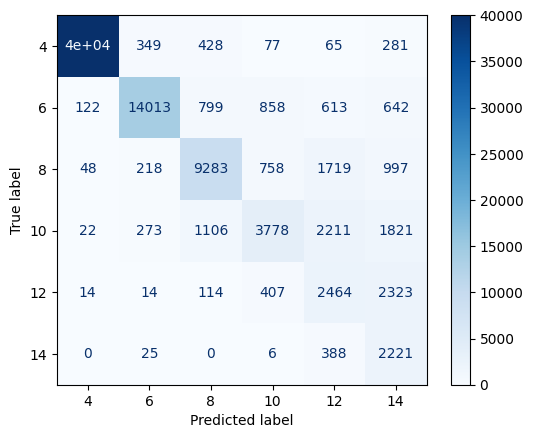

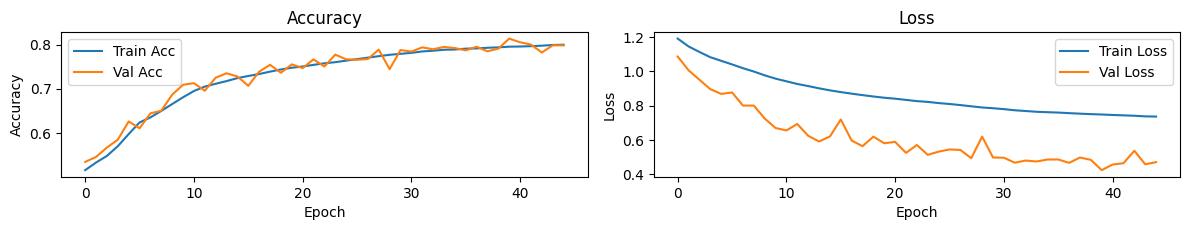

<Figure size 800x600 with 0 Axes>

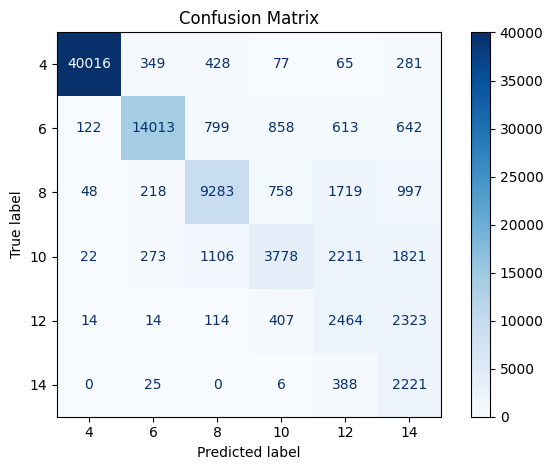


Model saved as wce_model_leakyrelu_weighted_new_11.h5


In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, ReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if tf.test.is_gpu_available():
    print("GPU is available and will be used!")
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(e)

# Load and preprocess data
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path)

    # Normalize input features
    scaler = MinMaxScaler()
    X = scaler.fit_transform(df[['A', 'target_error']].values)

    # Encode labels
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df['label_k'])

    # Split data
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    return X_train, X_val, X_test, y_train, y_val, y_test, label_encoder

# Build model with LeakyReLU
def build_model(input_dim, num_classes):
    model = Sequential([
        Dense(128, input_dim=input_dim, use_bias=False),  # Hadamard-like weighting
        ReLU(),
        Dense(64),
        ReLU(),
        Dense(32),
        ReLU(),
        Dense(64),
        ReLU(),
        Dense(32),
        ReLU(),
        Dense(16),
        ReLU(),
        Dense(num_classes, activation='softmax')  # Identity replaced with softmax for classification
     ])


    model.compile(optimizer=Adam(learning_rate=0.0004),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Main
file_path = '/kaggle/input/wce-dataset/wce_dataset.csv'  # Adjust if needed
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder = load_and_preprocess_data(file_path)

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

# Build and train model
model = build_model(input_dim=X_train.shape[1], num_classes=len(label_encoder.classes_))
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=50,
                    batch_size=50,
                    verbose=1,
                    callbacks=[early_stopping],
                    class_weight=class_weight_dict)

# Evaluate and predict
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

y_pred = model.predict(X_test).argmax(axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')
plt.savefig('/kaggle/working/confusion_matrix_leakyrelu_weighted_new_11.png')

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_.astype(str)))

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(2, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/training_history_leakyrelu_weighted_new_11.png')

# Create a NEW figure for the confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', values_format='d')  # 'd' for integer formatting
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()  # Show the confusion matri

# Save model
model.save('/kaggle/working/wce_model_leakyrelu_weighted_new_11.h5')
print("\nModel saved as wce_model_leakyrelu_weighted_new_11.h5")